# Project 1: Fast Food Marketing Campaign A/B Test

### Name: Shaima Alqahtani

## Scenario
---
A fast-food chain plans to add a new item to its menu. However, they are still undecided between three possible marketing campaigns for promoting the new product. In order to determine which promotion has the greatest effect on sales, the new item is introduced at locations in several randomly selected markets. A different promotion is used at each location, and the weekly sales of the new item are recorded for the first four weeks.

## Goal
----
Evaluate A/B testing results and decide which marketing strategy works the best.

## Columns
---
- MarketID: unique identifier for market
- MarketSize: size of market area by sales
- LocationID: unique identifier for store location
- AgeOfStore: age of store in years
- Promotion: one of three promotions that were tested
- week: one of four weeks when the promotions were run
- SalesInThousands: sales amount for a specific LocationID, Promotion, and week

### Step 1: Load and Explore Data

In [ ]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Dell\OneDrive\سطح المكتب\B5\content\W2\Project\p1\WA_Marketing-Campaign.csv")

In [3]:
print(df.head())

   MarketID MarketSize  LocationID  AgeOfStore  Promotion  week  \
0         1     Medium           1           4          3     1   
1         1     Medium           1           4          3     2   
2         1     Medium           1           4          3     3   
3         1     Medium           1           4          3     4   
4         1     Medium           2           5          2     1   

   SalesInThousands  
0             33.73  
1             35.67  
2             29.03  
3             39.25  
4             27.81  


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB
None


In [5]:
print(df.isnull().sum())

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64


### Step 2: Descriptive Analysis

In [ ]:
# Average Sales per Promotion
avg_sales = df.groupby("Promotion")["SalesInThousands"].mean()
print(avg_sales)

Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64


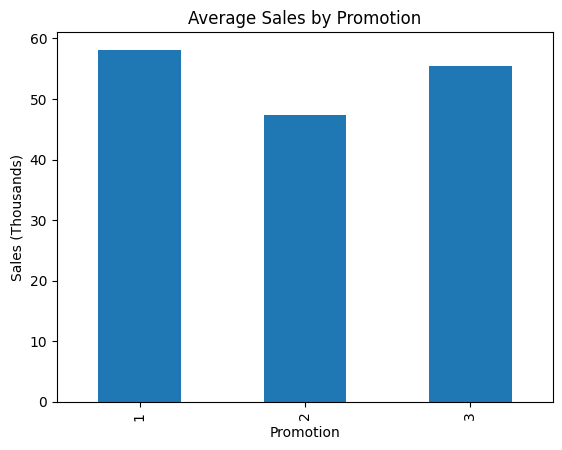

In [9]:
import matplotlib.pyplot as plt

avg_sales.plot(kind='bar')
plt.title("Average Sales by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Sales (Thousands)")
plt.show()

### Step 3: Hypothesis Testing (ANOVA)

Hypotheses:
- H₀ (Null Hypothesis):
There is no significant difference in sales between promotions.
- H₁ (Alternative Hypothesis):
At least one promotion performs differently.

In [10]:
from scipy import stats

# Separate groups
promo1 = df[df["Promotion"] == 1]["SalesInThousands"]
promo2 = df[df["Promotion"] == 2]["SalesInThousands"]
promo3 = df[df["Promotion"] == 3]["SalesInThousands"]

# ANOVA test
f_stat, p_value = stats.f_oneway(promo1, promo2, promo3)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 21.953485793080674
p-value: 6.765849261408834e-10


In [11]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0 → There is a significant difference between promotions.")
else:
    print("Fail to reject H0 → No significant difference between promotions.")

Reject H0 → There is a significant difference between promotions.


- If p-value < 0.05 → Reject H₀
→ There is a statistically significant difference between promotions.
- If p-value ≥ 0.05 → Fail to reject H₀
→ Promotions perform similarly.

### Step 4: Find the Best Promotion

In [12]:
best_promo = avg_sales.idxmax()
print("Best Promotion:", best_promo)

Best Promotion: 1


### Step 5: Final Conclusion
**Promotion 1** has the highest average sales.
The ANOVA test shows that the difference is **significant**
Therefore, **Promotion 1 is the best choice for the marketing campaign.**